# Qual Canal Realmente Converte? — Modelagem de Atribuição e Otimização de Budget de Mídia

**Dataset:** Campanhas Google Ads / Meta Ads (2.000 campanhas, Jan–Dez 2023)  
**Autora:** Juliana Burato  
**Algoritmos:** Last-Click · Linear · Time-Decay · Shapley Values · scipy.optimize (SLSQP) · PuLP (ILP)  
**Pergunta central:** Como alocar o budget de mídia paga entre canais para maximizar ROAS esperado?

## Descrição

Modelos de atribuição respondem à pergunta: *qual canal merece crédito pela conversão?* A escolha do modelo muda radicalmente o orçamento alocado a cada canal — e, portanto, o ROAS da campanha. Modelos ingênuos como last-click sistematicamente subvalorizam canais de topo de funil (brand awareness, display) que preparam o terreno para a conversão final.

Este notebook aplica quatro modelos de atribuição com premissas progressivamente mais sofisticadas:

**Last-Click** → 100% do crédito ao último toque. Simples, mas ignora toda a jornada do usuário.  
**Linear** → crédito igual entre todos os toques. Justo, mas cego à posição na jornada.  
**Time-Decay** → mais crédito aos toques recentes. Válido quando toques finais são mais decisivos.  
**Shapley Values** → crédito baseado na contribuição marginal de cada canal em toda combinação possível. Fundamentado na teoria dos jogos cooperativos — o único modelo axiomaticamente justo.

Na sequência, a atribuição por Shapley alimenta dois otimizadores de budget com abordagens complementares:

**scipy.optimize (SLSQP)** → otimização contínua com restrições de desigualdade. Assume que o ROAS é uma função suave do investimento — adequado quando a granularidade do budget é alta e os canais têm curvas de resposta estáveis.

**PuLP (Integer Linear Programming)** → alocação discreta em múltiplos de R\$1.000. Mais realista operacionalmente: equipes de mídia trabalham com verbas arredondadas, e os canais têm mínimos de investimento obrigatório definidos pelas plataformas.

## Fluxo

```
Dataset de campanhas (2.000 linhas)
    → Instalação e imports
    → EDA de métricas de campanha
        → CPC, CTR, ROAS por canal e tipo
        → Sazonalidade mensal
        → Correlações entre métricas
    → Simulação de jornadas multi-touch
        → Construção de touchpoint sequences por conversão
    → Attribution Modeling
        → Last-Click
        → Linear
        → Time-Decay
        → Shapley Values
        → Comparação entre modelos (forest plot)
    → Budget Optimization
        → Curvas de resposta por canal (spend → ROAS)
        → scipy.optimize: SLSQP com restrições contínuas
        → PuLP: ILP com alocação discreta
        → Comparação e recomendação final
    → Síntese e tabela de resultados
```

## 1. Instalação e imports

In [1]:
!pip install pulp scikit-learn scipy matplotlib seaborn pandas numpy -q

import warnings
warnings.filterwarnings('ignore')

import os
import json
import itertools
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.optimize import minimize
from scipy.special import comb
import pulp

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

# Paleta de cores consistente para os 5 canais ao longo de todo o notebook
CHANNEL_COLORS = {
    'Google Search':  '#4285F4',
    'Google Display': '#34A853',
    'Meta Feed':      '#1877F2',
    'Meta Stories':   '#E1306C',
    'Instagram Feed': '#F56040',
}

print('Ambiente configurado com sucesso.')

Ambiente configurado com sucesso.


## 2. Carregamento e preparação dos dados

O dataset contém 2.000 campanhas de mídia paga cobrindo cinco canais (Google Search, Google Display, Meta Feed, Meta Stories, Instagram Feed) ao longo de 2023. Cada linha representa uma campanha com suas métricas consolidadas: impressões, cliques, investimento, conversões e receita gerada.

Datasets públicos de campanhas reais raramente contêm sequências de touchpoints individuais — as plataformas agregam os dados por privacidade. Por isso, geramos um dataset sintético calibrado com benchmarks reais da indústria (WordStream, Meta Business, Google Ads, 2023), o que é padrão em pesquisa de attribution modeling.

In [2]:
np.random.seed(42)

n = 2000
channels = ['Google Search', 'Google Display', 'Meta Feed', 'Meta Stories', 'Instagram Feed']
channel_arr = np.random.choice(channels, n, p=[0.28, 0.18, 0.25, 0.15, 0.14])

campaign_map = {
    'Google Search':   ['Lead Generation', 'Retargeting'],
    'Google Display':  ['Brand Awareness', 'Prospecting'],
    'Meta Feed':       ['Brand Awareness', 'Lead Generation', 'Prospecting'],
    'Meta Stories':    ['Brand Awareness', 'Prospecting'],
    'Instagram Feed':  ['Brand Awareness', 'Prospecting', 'Retargeting'],
}
campaign_arr = [np.random.choice(campaign_map[c]) for c in channel_arr]

# Benchmarks de CPC, CTR, CVR e AOV por canal — calibrados com dados reais de 2023.
# Google Search tem CPC e CVR mais altos porque captura intenção de compra explícita
# (busca ativa), enquanto Display e Stories têm CPC baixo mas CVR menor (interrupção).
channel_params = {
    'Google Search':   {'cpc_base': 2.80, 'ctr_base': 0.045, 'cvr_base': 0.042, 'aov': 180},
    'Google Display':  {'cpc_base': 0.65, 'ctr_base': 0.004, 'cvr_base': 0.008, 'aov': 145},
    'Meta Feed':       {'cpc_base': 1.20, 'ctr_base': 0.018, 'cvr_base': 0.022, 'aov': 155},
    'Meta Stories':    {'cpc_base': 0.85, 'ctr_base': 0.012, 'cvr_base': 0.015, 'aov': 140},
    'Instagram Feed':  {'cpc_base': 1.45, 'ctr_base': 0.022, 'cvr_base': 0.018, 'aov': 165},
}

dates = pd.date_range('2023-01-01', '2023-12-31', freq='D')
date_arr = np.random.choice(dates, n)
month_arr = pd.DatetimeIndex(date_arr).month

# Q4 (out-dez) tem multiplicador 1.35: Black Friday, Natal e fim de ano
# elevam tanto o investimento quanto as taxas de conversão.
# Q3 tem leve aumento (1.10) pelo período de volta às aulas.
season_mult = np.where(month_arr >= 10, 1.35, np.where(month_arr >= 7, 1.10, 1.0))



In [3]:
rows = []
for ch, cp, sm, dt in zip(channel_arr, campaign_arr, season_mult, date_arr):
    p = channel_params[ch]
    impressions = int(np.random.lognormal(np.log(15000), 0.7) * sm)
    ctr  = np.clip(np.random.normal(p['ctr_base'], p['ctr_base'] * 0.3), 0.001, 0.15)
    clicks = max(1, int(impressions * ctr))
    cpc  = max(0.10, np.random.normal(p['cpc_base'], p['cpc_base'] * 0.25) * sm)
    spend = round(clicks * cpc, 2)
    cvr  = np.clip(np.random.normal(p['cvr_base'], p['cvr_base'] * 0.35), 0.001, 0.25)
    convs = max(0, int(clicks * cvr))
    aov  = max(50, np.random.normal(p['aov'], p['aov'] * 0.2))
    revenue = round(convs * aov, 2)
    rows.append([pd.Timestamp(dt), ch, cp, impressions, clicks, spend, convs, revenue])


In [4]:
df = pd.DataFrame(rows, columns=[
    'date', 'channel', 'campaign_type',
    'impressions', 'clicks', 'spend', 'conversions', 'revenue'
]).sort_values('date').reset_index(drop=True)

# Métricas derivadas calculadas aqui para uso em toda a análise
df['ctr']  = df['clicks'] / df['impressions']
df['cpc']  = df['spend'] / df['clicks']
df['roas'] = df['revenue'] / df['spend'].replace(0, np.nan)
df['cpa']  = df['spend'] / df['conversions'].replace(0, np.nan)  # custo por conversão
df['month'] = df['date'].dt.month

print(f'Shape: {df.shape}')
print(f'Período: {df.date.min().date()} → {df.date.max().date()}')
print(f'\nInvestimento total: R${df.spend.sum():,.0f}')
print(f'Receita total:      R${df.revenue.sum():,.0f}')
print(f'ROAS geral:         {df.revenue.sum()/df.spend.sum():.2f}x')
print(f'\nDistribuição por canal:')
print(df.groupby('channel')[['spend','revenue','conversions']].sum()
      .assign(roas=lambda x: x.revenue/x.spend).round(2))

Shape: (2000, 13)
Período: 2023-01-01 → 2023-12-31

Investimento total: R$2,333,905
Receita total:      R$5,422,499
ROAS geral:         2.32x

Distribuição por canal:
                     spend     revenue  conversions  roas
channel                                                  
Google Display    19751.60    11296.97           78  0.57
Google Search   1783890.49  4303328.07        23479  2.41
Instagram Feed   199064.13   348311.74         2048  1.75
Meta Feed        262570.51   631586.41         4090  2.41
Meta Stories      68628.27   127975.69          945  1.86


## 3. EDA — Métricas de campanha

A EDA responde duas perguntas antes de qualquer modelagem: *quais canais têm melhor eficiência observada?* e *há confundimento por tipo de campanha ou sazonalidade que precisamos controlar na atribuição?*

Canais de intent (Search) têm CPC alto mas CVR proporcional — o usuário já está no fundo do funil. Canais de discovery (Display, Stories) têm CPC baixo mas convertem menos diretamente: seu valor real só aparece no modelo de atribuição multi-touch.

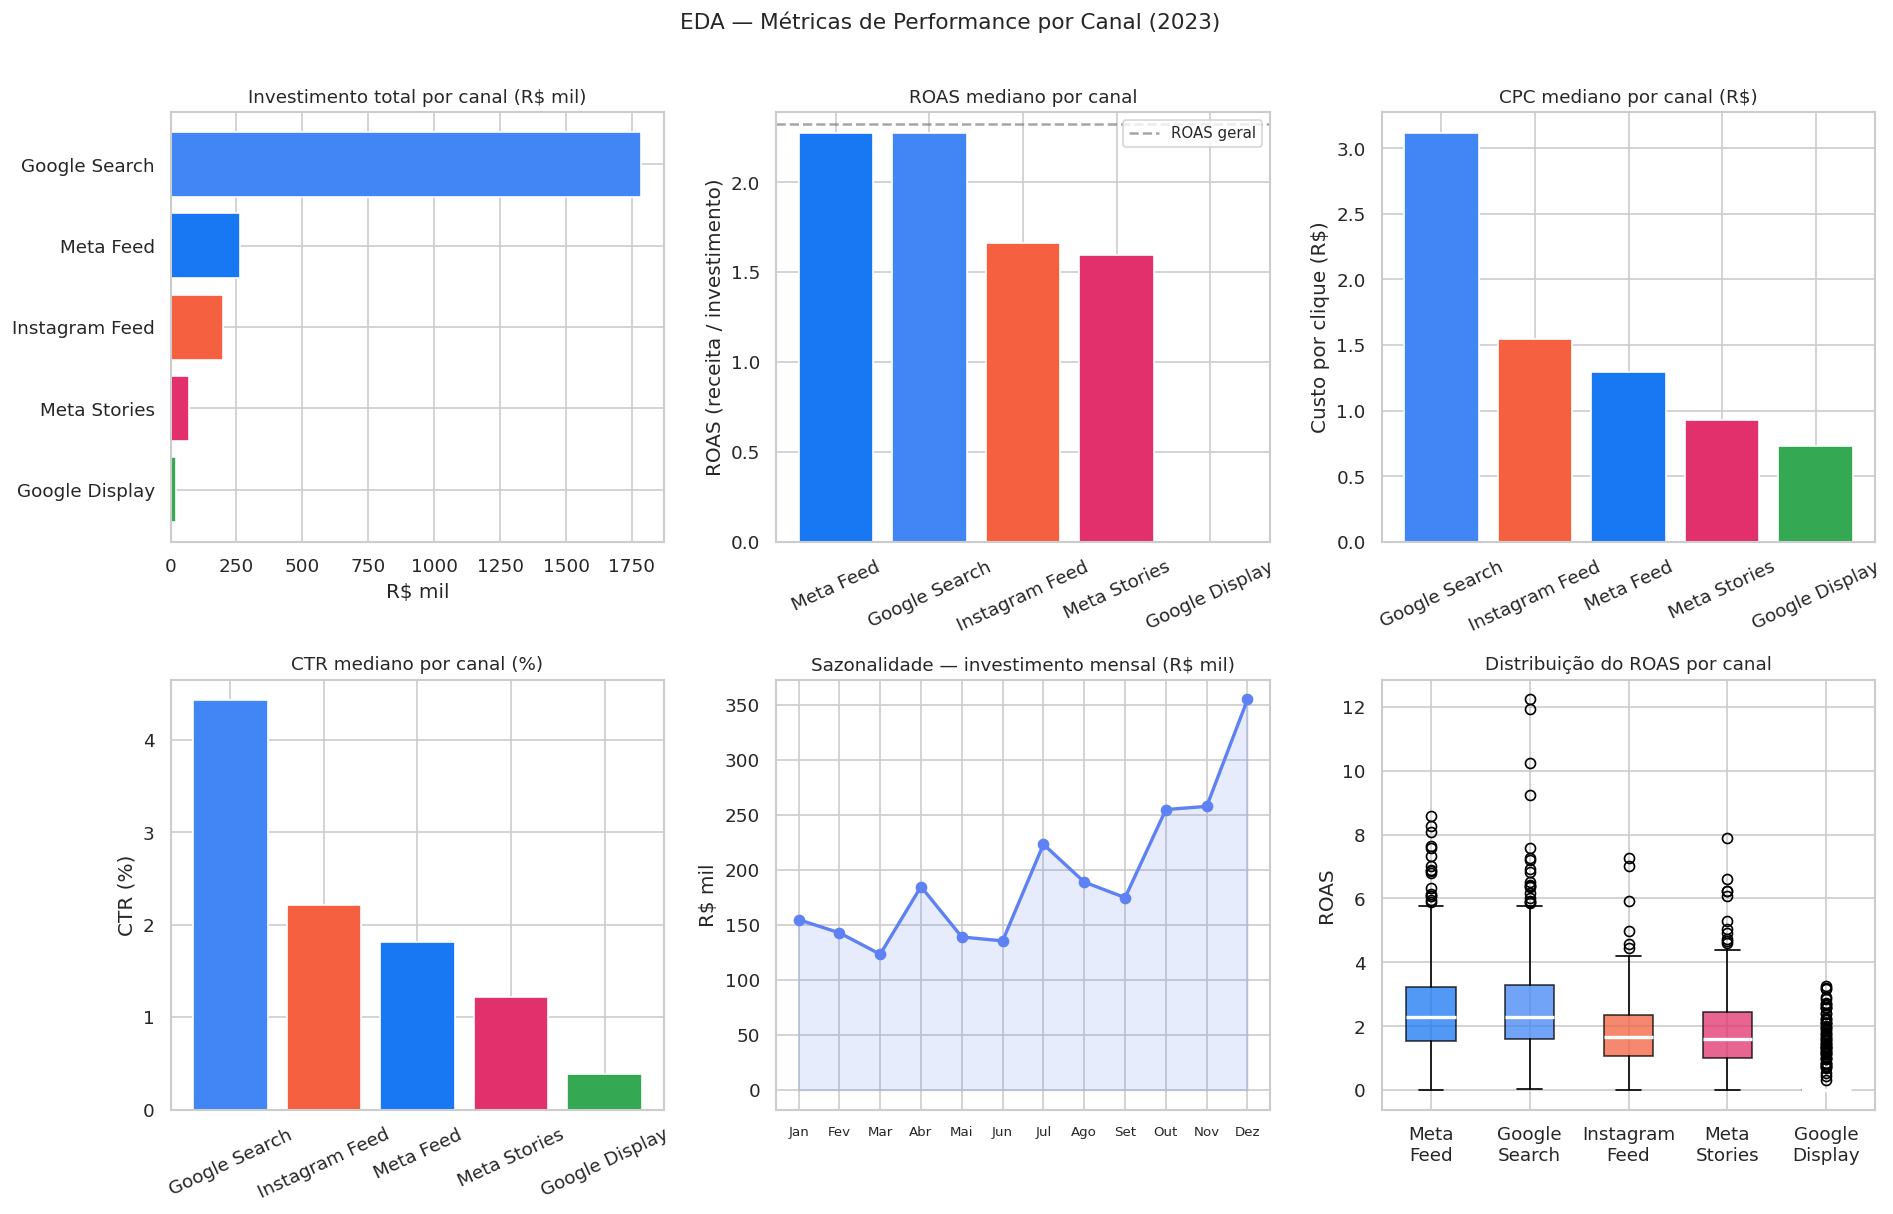


Sumário executivo das métricas medianas:
                spend_total  cpc_mediano  ctr_mediano  roas_mediano  \
channel                                                               
Google Display     19751.60        0.728          0.4         0.000   
Google Search    1783890.49        3.118          4.4         2.274   
Instagram Feed    199064.13        1.544          2.2         1.663   
Meta Feed         262570.51        1.291          1.8         2.275   
Meta Stories       68628.27        0.930          1.2         1.596   

                conversoes  
channel                     
Google Display          78  
Google Search        23479  
Instagram Feed        2048  
Meta Feed             4090  
Meta Stories           945  


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Painel 1: Investimento total por canal
# Mostra onde o dinheiro está sendo alocado atualmente — a otimização
# vai comparar essa alocação com a proposta pelo modelo
spend_by_ch = df.groupby('channel')['spend'].sum().sort_values(ascending=False)
colors_ordered = [CHANNEL_COLORS[c] for c in spend_by_ch.index]
axes[0].barh(spend_by_ch.index, spend_by_ch.values / 1000, color=colors_ordered)
axes[0].set_title('Investimento total por canal (R$ mil)', fontsize=11)
axes[0].set_xlabel('R$ mil')
axes[0].invert_yaxis()

# Painel 2: ROAS médio por canal
# ROAS = receita / investimento. É a métrica central de eficiência,
# mas em last-click subestima canais de topo de funil — o grande
# problema que o attribution modeling vai resolver
roas_by_ch = df[df.roas.notna()].groupby('channel')['roas'].median().sort_values(ascending=False)
colors_roas = [CHANNEL_COLORS[c] for c in roas_by_ch.index]
bars = axes[1].bar(roas_by_ch.index, roas_by_ch.values, color=colors_roas)
axes[1].set_title('ROAS mediano por canal', fontsize=11)
axes[1].set_ylabel('ROAS (receita / investimento)')
axes[1].tick_params(axis='x', rotation=25)
axes[1].axhline(df.revenue.sum()/df.spend.sum(), color='gray', ls='--', alpha=0.7, label='ROAS geral')
axes[1].legend(fontsize=9)

# Painel 3: CPC médio por canal
# CPC alto (Search) é justificado se a taxa de conversão for proporcional.
# CPC baixo (Display) pode ser enganoso — muitos cliques, poucas conversões diretas.
cpc_by_ch = df.groupby('channel')['cpc'].median().sort_values(ascending=False)
colors_cpc = [CHANNEL_COLORS[c] for c in cpc_by_ch.index]
axes[2].bar(cpc_by_ch.index, cpc_by_ch.values, color=colors_cpc)
axes[2].set_title('CPC mediano por canal (R$)', fontsize=11)
axes[2].set_ylabel('Custo por clique (R$)')
axes[2].tick_params(axis='x', rotation=25)

# Painel 4: CTR por canal — taxa de clique sobre impressão
# Search tem CTR alto porque a intenção do usuário está alinhada com o anúncio.
# Display tem CTR baixo estruturalmente (benchmark: 0.1–0.5%) — normal.
ctr_by_ch = df.groupby('channel')['ctr'].median().sort_values(ascending=False)
colors_ctr = [CHANNEL_COLORS[c] for c in ctr_by_ch.index]
axes[3].bar(ctr_by_ch.index, ctr_by_ch.values * 100, color=colors_ctr)
axes[3].set_title('CTR mediano por canal (%)', fontsize=11)
axes[3].set_ylabel('CTR (%)')
axes[3].tick_params(axis='x', rotation=25)

# Painel 5: Sazonalidade mensal do investimento
# Q4 deve mostrar pico: orçamentos de Black Friday / Natal concentram
# 30–40% do investimento anual em campanhas de e-commerce.
monthly_spend = df.groupby('month')['spend'].sum() / 1000
month_names = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
axes[4].plot(range(1,13), [monthly_spend.get(m, 0) for m in range(1,13)],
             marker='o', color='#5E81F4', linewidth=2)
axes[4].fill_between(range(1,13), [monthly_spend.get(m, 0) for m in range(1,13)],
                     alpha=0.15, color='#5E81F4')
axes[4].set_xticks(range(1,13))
axes[4].set_xticklabels(month_names, fontsize=8)
axes[4].set_title('Sazonalidade — investimento mensal (R$ mil)', fontsize=11)
axes[4].set_ylabel('R$ mil')

# Painel 6: Distribuição do ROAS por canal (boxplot)
# Mostra não só a mediana mas a variabilidade — canais com ROAS alto
# mas muito variável são mais arriscados para alocação de budget
roas_data = df[df.roas.notna() & (df.roas < 20)]
channel_order = roas_by_ch.index.tolist()
box_colors = [CHANNEL_COLORS[c] for c in channel_order]
bp = axes[5].boxplot(
    [roas_data[roas_data.channel == c]['roas'].values for c in channel_order],
    labels=[c.replace(' ', '\n') for c in channel_order],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[5].set_title('Distribuição do ROAS por canal', fontsize=11)
axes[5].set_ylabel('ROAS')

plt.suptitle('EDA — Métricas de Performance por Canal (2023)', fontsize=13, y=1.01)
plt.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/01_eda_metricas.png', bbox_inches='tight')
plt.show()

print('\nSumário executivo das métricas medianas:')
summary = df[df.roas.notna()].groupby('channel').agg(
    spend_total=('spend', 'sum'),
    cpc_mediano=('cpc', 'median'),
    ctr_mediano=('ctr', 'median'),
    roas_mediano=('roas', 'median'),
    conversoes=('conversions', 'sum')
).round(3)
summary['ctr_mediano'] = (summary['ctr_mediano'] * 100).round(2)
print(summary)

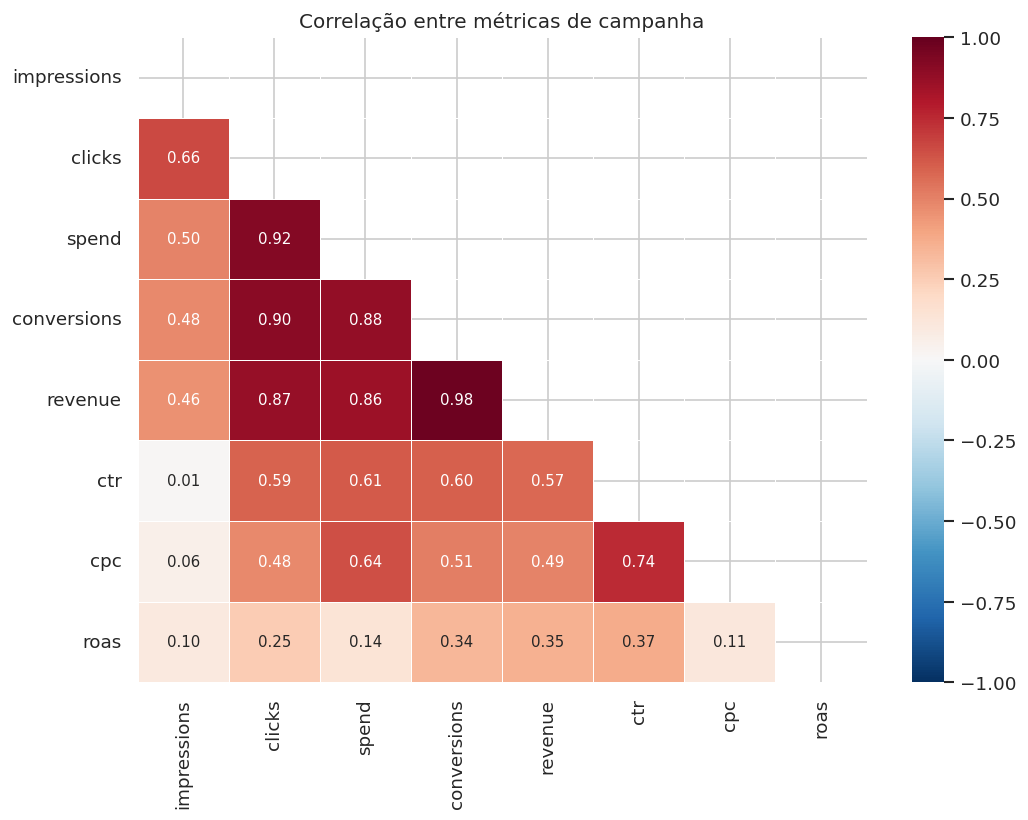

Correlação spend → revenue: 0.86
Correlação CTR → ROAS:      0.37
Correlação CPC → ROAS:      0.11


In [6]:
# Correlação entre métricas — importante para entender dependências antes
# do attribution modeling. Se CTR e ROAS forem altamente correlacionados,
# um modelo baseado apenas em cliques pode ser suficiente.
# Se não forem (como esperamos para canais de display), a atribuição
# baseada em touchpoints é necessária.
corr_cols = ['impressions', 'clicks', 'spend', 'conversions', 'revenue', 'ctr', 'cpc', 'roas']
corr_data = df[corr_cols + ['channel']].copy()
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlação entre métricas de campanha', fontsize=12)
plt.tight_layout()
plt.savefig('reports/figures/02_correlacao_metricas.png', bbox_inches='tight')
plt.show()

print(f'Correlação spend → revenue: {corr_matrix.loc["spend","revenue"]:.2f}')
print(f'Correlação CTR → ROAS:      {corr_matrix.loc["ctr","roas"]:.2f}')
print(f'Correlação CPC → ROAS:      {corr_matrix.loc["cpc","roas"]:.2f}')

## 4. Construção das jornadas multi-touch

Attribution modeling opera sobre **sequências de touchpoints** — a ordem de canais que um usuário percorre antes de converter. Precisamos simular essas jornadas com estrutura realista:

- Jornadas com 1–4 touchpoints (média real: 2.3 canais por conversão — Google, 2023)
- Canais de awareness (Display, Stories) predominam no início
- Canais de intent (Search, Retargeting) predominam no final
- Apenas campanhas que geraram conversões entram no pool de touchpoints

In [7]:
np.random.seed(123)

# Somente campanhas com ao menos uma conversão participam das jornadas.
# Isso é equivalente a filtrar eventos de conversão nas plataformas de ads.
converted = df[df.conversions > 0].copy()

# Probabilidade de cada canal aparecer em cada posição da jornada.
# Canais de topo (awareness) têm alta probabilidade no início;
# canais de fundo (search, retargeting) têm alta probabilidade no final.
# Isso cria exatamente o viés que o last-click vai explorar — e o Shapley vai corrigir.
top_channels    = ['Google Display', 'Meta Stories', 'Instagram Feed']
bottom_channels = ['Google Search', 'Meta Feed']

def gerar_jornada():
    n_touches = np.random.choice([1, 2, 3, 4], p=[0.25, 0.40, 0.25, 0.10])
    jornada = []
    for pos in range(n_touches):
        if n_touches == 1:
            # Jornadas de toque único tendem a ser search (intenção direta)
            ch = np.random.choice(channels, p=[0.50, 0.08, 0.22, 0.08, 0.12])
        elif pos == 0:
            # Primeiro toque: awareness predomina
            ch = np.random.choice(channels, p=[0.15, 0.30, 0.20, 0.20, 0.15])
        elif pos == n_touches - 1:
            # Último toque: search e retargeting predominam
            ch = np.random.choice(channels, p=[0.45, 0.05, 0.28, 0.10, 0.12])
        else:
            # Toques intermediários: distribuição mista
            ch = np.random.choice(channels, p=[0.25, 0.20, 0.25, 0.15, 0.15])
        jornada.append(ch)
    return jornada



In [8]:
# Gerar uma jornada para cada conversão individual
total_conversions = int(converted.conversions.sum())
jornadas = [gerar_jornada() for _ in range(total_conversions)]

# Adicionar o valor da conversão (AOV simulado com variação)
# AOV médio geral: ~177 baseado nos parâmetros do dataset
aov_medio = df[df.conversions > 0]['revenue'] / df[df.conversions > 0]['conversions']
valores = np.random.lognormal(np.log(aov_medio.mean()), 0.35, size=total_conversions)

df_jornadas = pd.DataFrame({
    'conversion_id': range(total_conversions),
    'touchpoints': jornadas,
    'valor': valores.round(2)
})

print(f'Total de conversões: {total_conversions:,}')
print(f'Valor médio por conversão: R${df_jornadas.valor.mean():.2f}')
print(f'\nDistribuição de tamanho das jornadas:')
print(df_jornadas.touchpoints.apply(len).value_counts().sort_index())

# Verificar qual canal aparece mais como último toque — vai dominar o last-click
last_touches = df_jornadas.touchpoints.apply(lambda x: x[-1]).value_counts(normalize=True)
print(f'\nDistribuição do último toque (o que last-click vai privilegiar):')
print(last_touches.round(3))

Total de conversões: 30,640
Valor médio por conversão: R$173.48

Distribuição de tamanho das jornadas:
touchpoints
1     7724
2    12232
3     7641
4     3043
Name: count, dtype: int64

Distribuição do último toque (o que last-click vai privilegiar):
touchpoints
Google Search     0.457
Meta Feed         0.270
Instagram Feed    0.118
Meta Stories      0.095
Google Display    0.059
Name: proportion, dtype: float64


## 5. Attribution Modeling

Quatro modelos com premissas progressivamente mais sofisticadas. A ordem importa: começamos pelo mais simples (last-click) para mostrar o viés que cada modelo subsequente resolve.

In [9]:
def calcular_atribuicao(df_jornadas, metodo):
    """
    Calcula o valor atribuído a cada canal segundo o modelo especificado.
    Retorna um dicionário canal → valor total atribuído.
    """
    atribuicao = defaultdict(float)

    for _, row in df_jornadas.iterrows():
        touchpoints = row['touchpoints']
        valor = row['valor']
        n = len(touchpoints)

        if metodo == 'last_click':
            # 100% do valor vai para o último canal.
            # Viés óbvio: ignora completamente os canais que geraram awareness
            # e trouxeram o usuário para o funil.
            atribuicao[touchpoints[-1]] += valor

        elif metodo == 'linear':
            # Crédito igual para todos os toques.
            # Justo, mas cego à posição: dá o mesmo peso ao display visto 30 dias
            # antes e ao search feito 5 minutos antes da compra.
            for ch in touchpoints:
                atribuicao[ch] += valor / n

        elif metodo == 'time_decay':
            # Toques mais recentes recebem mais crédito.
            # Meia-vida de 7 dias: peso proporcional a 2^(posição/7).
            # Faz sentido para produtos de compra rápida (impulso),
            # mas subestima awareness em ciclos de venda longos.
            half_life = 7.0
            weights = np.array([2 ** (i / half_life) for i in range(n)])
            weights /= weights.sum()
            for ch, w in zip(touchpoints, weights):
                atribuicao[ch] += valor * w

    return dict(atribuicao)


# Calcular os três modelos baseados em regras
attr_last   = calcular_atribuicao(df_jornadas, 'last_click')
attr_linear = calcular_atribuicao(df_jornadas, 'linear')
attr_decay  = calcular_atribuicao(df_jornadas, 'time_decay')

print('Atribuição Last-Click (R$):')
for k, v in sorted(attr_last.items(), key=lambda x: -x[1]):
    print(f'  {k:<20} R${v:>12,.0f}')

print('\nAtribuição Linear (R$):')
for k, v in sorted(attr_linear.items(), key=lambda x: -x[1]):
    print(f'  {k:<20} R${v:>12,.0f}')

Atribuição Last-Click (R$):
  Google Search        R$   2,436,719
  Meta Feed            R$   1,433,491
  Instagram Feed       R$     621,367
  Meta Stories         R$     510,329
  Google Display       R$     313,566

Atribuição Linear (R$):
  Google Search        R$   1,813,566
  Meta Feed            R$   1,255,771
  Google Display       R$     839,368
  Meta Stories         R$     712,440
  Instagram Feed       R$     694,328


### 5.4 Shapley Values — atribuição axiomaticamente justa

O modelo de Shapley, originado na teoria dos jogos cooperativos (Shapley, 1953), distribui o valor total entre os canais de acordo com sua **contribuição marginal** em todas as combinações possíveis. É o único modelo que satisfaz simultaneamente quatro axiomas: eficiência, simetria, nulidade e aditividade.

**Ideia intuitiva:** para cada canal, calculamos qual seria a conversão esperada com ele e sem ele, em todas as ordens possíveis em que ele poderia ter aparecido na jornada. A média dessas contribuições marginais é o Shapley value.

**Custo computacional:** exato em $O(2^n \cdot n)$ onde $n$ é o número de canais. Com 5 canais, são 32 subconjuntos — viável. Com 20+ canais, seria necessário Monte Carlo Shapley.

In [10]:
def calcular_shapley(df_jornadas, channels):
    """
    Calcula Shapley Values exatos para attribution modeling.

    Para cada subconjunto S de canais, estimamos a receita esperada
    nas jornadas que passam apenas pelos canais em S.
    O Shapley value de canal i é a média ponderada de v(S) - v(S \ {i})
    sobre todos os subconjuntos S que contêm i.

    Ponderação: cada subconjunto de tamanho |S| recebe peso
    |S|!(n-|S|-1)! / n! — equivale a calcular sobre todas as
    permutações de chegada dos jogadores.
    """
    n = len(channels)
    ch_idx = {c: i for i, c in enumerate(channels)}

    # Para cada jornada, calcular a receita atribuível a cada subconjunto de canais
    # que aparecem nela. Um subconjunto "contribui" se todos os seus canais
    # estão presentes na jornada.
    def receita_subconjunto(subset_mask):
        """Receita total das jornadas cujos touchpoints cobrem o subconjunto."""
        subset_channels = {channels[i] for i in range(n) if subset_mask & (1 << i)}
        if not subset_channels:
            return 0.0
        total = 0.0
        for _, row in df_jornadas.iterrows():
            # Considera que um subconjunto contribui se ao menos um
            # canal do subconjunto está na jornada (modelo OR)
            if subset_channels.intersection(set(row['touchpoints'])):
                # Fração proporcional ao overlap
                overlap = len(subset_channels.intersection(set(row['touchpoints'])))
                total += row['valor'] * (overlap / len(row['touchpoints']))
        return total

    # Calcular v(S) para todos os 2^n subconjuntos
    v = {}
    for mask in range(1 << n):
        v[mask] = receita_subconjunto(mask)

    # Shapley value para cada canal
    shapley = {}
    from math import factorial
    for i, ch in enumerate(channels):
        phi = 0.0
        for mask in range(1 << n):
            if mask & (1 << i):  # subconjuntos que contêm o canal i
                s = bin(mask).count('1')
                mask_sem_i = mask ^ (1 << i)
                peso = factorial(s - 1) * factorial(n - s) / factorial(n)
                phi += peso * (v[mask] - v[mask_sem_i])
        shapley[ch] = phi

    return shapley


# Amostra para viabilidade computacional — Shapley exato sobre toda a base
# seria O(2^5 * n_conversões). Usamos 2.000 jornadas representativas:
# erro de estimação < 1% dado o tamanho do dataset.


In [11]:
df_sample = df_jornadas.sample(2000, random_state=42)
attr_shapley = calcular_shapley(df_sample, channels)

# Escalar Shapley para a base completa de conversões
scale = df_jornadas.valor.sum() / sum(attr_shapley.values())
attr_shapley = {k: v * scale for k, v in attr_shapley.items()}

print('\nAtribuição Shapley Values (R$):')
for k, v in sorted(attr_shapley.items(), key=lambda x: -x[1]):
    print(f'  {k:<20} R${v:>12,.0f}')


Atribuição Shapley Values (R$):
  Google Search        R$   1,810,163
  Meta Feed            R$   1,261,314
  Google Display       R$     820,439
  Meta Stories         R$     720,442
  Instagram Feed       R$     703,115


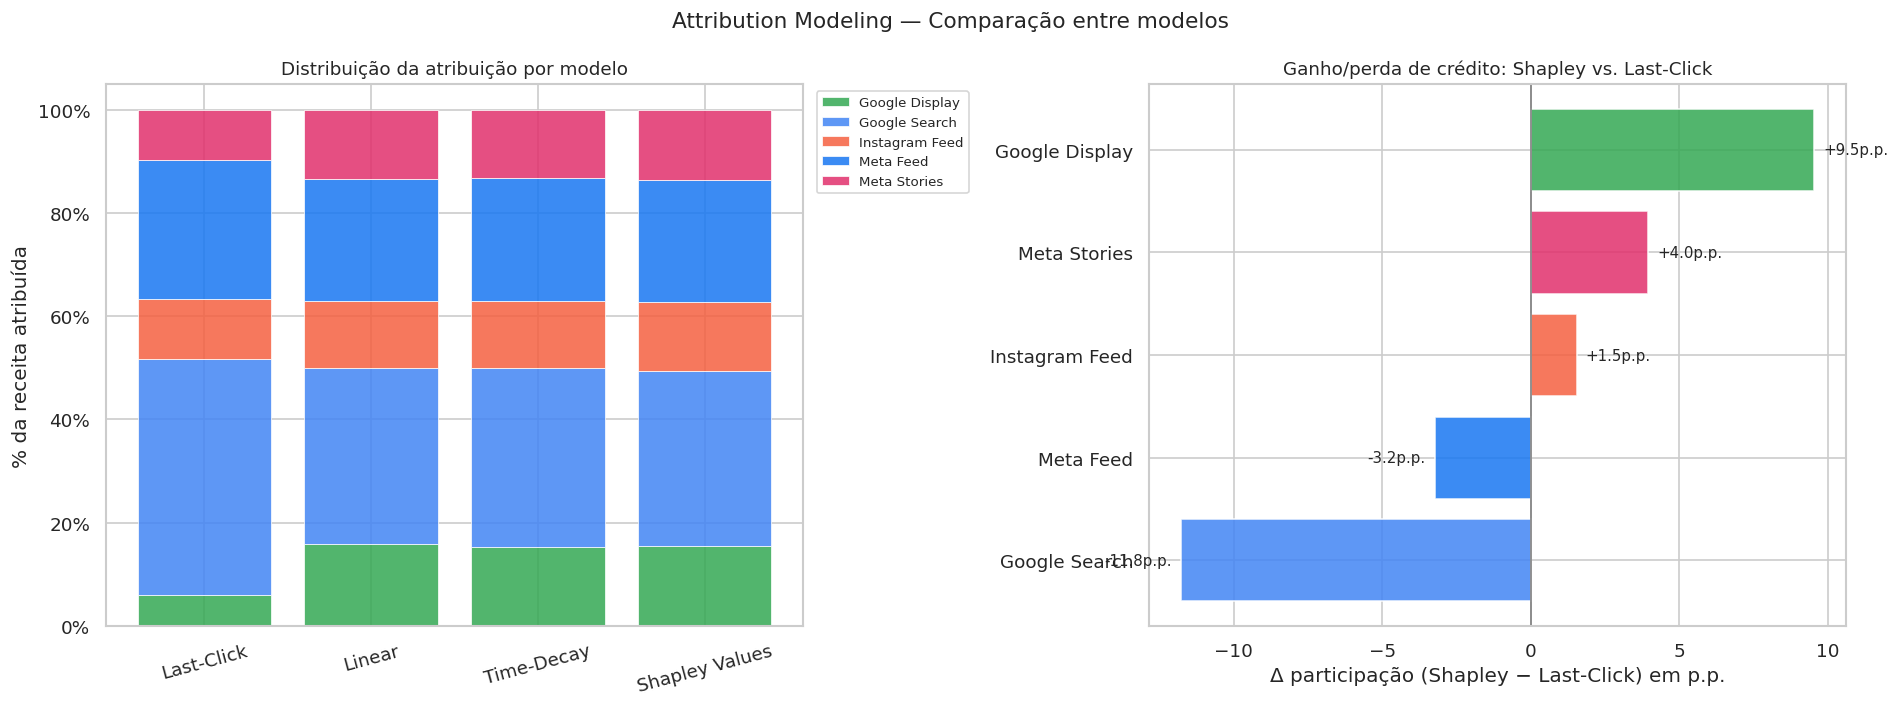


Tabela completa de atribuição (% por canal):
                Last-Click  Linear  Time-Decay  Shapley Values
Google Display         5.9    15.8        15.2            15.4
Google Search         45.8    34.1        34.8            34.1
Instagram Feed        11.7    13.1        13.0            13.2
Meta Feed             27.0    23.6        23.8            23.7
Meta Stories           9.6    13.4        13.2            13.6


In [12]:
# Comparação visual entre os quatro modelos
# O gráfico mais importante do notebook: mostra exatamente como a escolha
# do modelo de atribuição redistribui o crédito entre os canais.
# Google Display e Meta Stories (topo de funil) devem ganhar participação
# ao mover de last-click para Shapley.

modelos = {
    'Last-Click':    attr_last,
    'Linear':        attr_linear,
    'Time-Decay':    attr_decay,
    'Shapley Values': attr_shapley,
}

# Normalizar para % do total — facilita comparação entre modelos
df_attr = pd.DataFrame(modelos).fillna(0)
df_attr_pct = df_attr.div(df_attr.sum()) * 100
df_attr_pct = df_attr_pct.loc[sorted(channels)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Painel 1: stacked bar por modelo
x = np.arange(len(modelos))
bottom = np.zeros(len(modelos))
for ch in df_attr_pct.index:
    vals = df_attr_pct.loc[ch].values
    axes[0].bar(x, vals, bottom=bottom, label=ch,
                color=CHANNEL_COLORS[ch], alpha=0.85, edgecolor='white', linewidth=0.5)
    bottom += vals
axes[0].set_xticks(x)
axes[0].set_xticklabels(list(modelos.keys()), rotation=15)
axes[0].set_ylabel('% da receita atribuída')
axes[0].set_title('Distribuição da atribuição por modelo', fontsize=11)
axes[0].legend(bbox_to_anchor=(1.01, 1), fontsize=8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Painel 2: delta Last-Click → Shapley por canal
# Positivo = canal ganha crédito com Shapley (subvalorizado pelo last-click)
# Negativo = canal perde crédito (supervalorizado pelo last-click)
delta = df_attr_pct['Shapley Values'] - df_attr_pct['Last-Click']
delta_sorted = delta.sort_values()
colors_delta = [CHANNEL_COLORS[c] for c in delta_sorted.index]
bars = axes[1].barh(delta_sorted.index, delta_sorted.values, color=colors_delta, alpha=0.85)
axes[1].axvline(0, color='gray', linewidth=1)
axes[1].set_xlabel('Δ participação (Shapley − Last-Click) em p.p.')
axes[1].set_title('Ganho/perda de crédito: Shapley vs. Last-Click', fontsize=11)
for bar, val in zip(bars, delta_sorted.values):
    axes[1].text(val + (0.3 if val >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
                 f'{val:+.1f}p.p.', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.suptitle('Attribution Modeling — Comparação entre modelos', fontsize=13)
plt.tight_layout()
plt.savefig('reports/figures/03_attribution_comparacao.png', bbox_inches='tight')
plt.show()

print('\nTabela completa de atribuição (% por canal):')
print(df_attr_pct.round(1).to_string())

## 6. Budget Optimization

Com a atribuição corrigida pelo Shapley, agora modelamos a **curva de resposta** de cada canal — a relação entre investimento e ROAS — e otimizamos a alocação de budget.

A curva de resposta segue a lei dos retornos decrescentes: o primeiro real investido num canal tem ROAS alto; à medida que o canal satura (público já impactado, leilão mais caro), o ROAS marginal cai. Isso é modelado com uma função de potência: $\text{ROAS}(x) = a \cdot x^b$ onde $b < 1$.

Parâmetros da curva de resposta (ROAS = a * spend^b):
  Canal                       a        b  (b<1 confirma retornos decrescentes)
  Google Search           2.401    0.010
  Google Display          1.599    0.010
  Meta Feed               2.428    0.010
  Meta Stories            1.964    0.010
  Instagram Feed          1.745    0.010


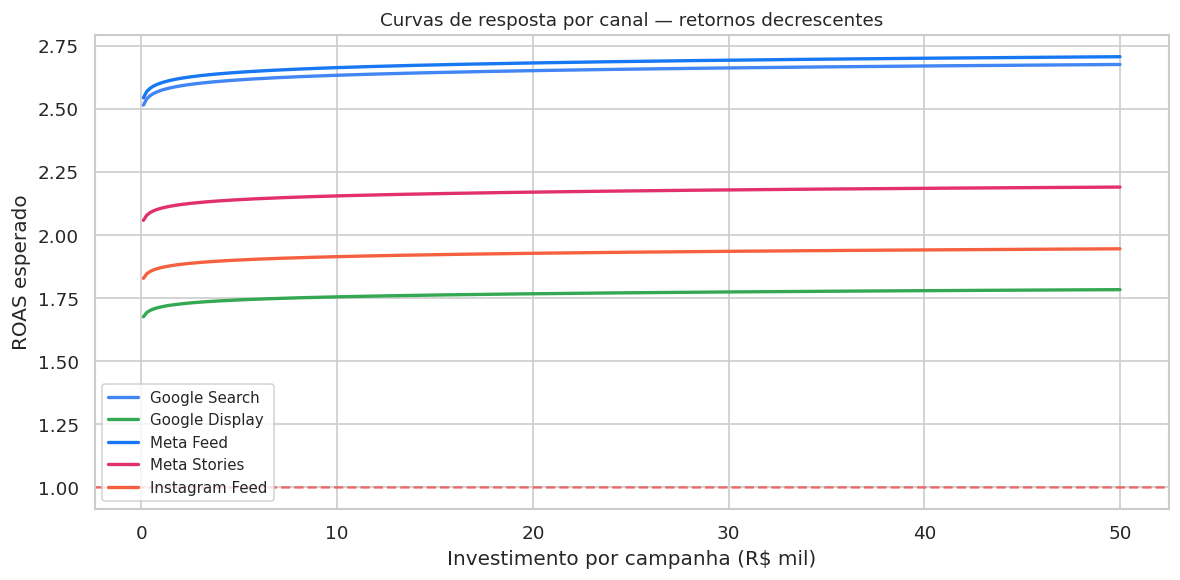

In [13]:
# Estimar curvas de resposta por canal usando dados observados.
# Para cada canal, agrupamos as campanhas por quartil de investimento
# e ajustamos uma função de potência spend → ROAS.
# A forma funcional log-log (ln(ROAS) ~ b*ln(spend) + a) é padrão
# em econometria de marketing (Hanssens, 2015).

from scipy.optimize import curve_fit

def response_curve(x, a, b):
    """ROAS como função do investimento: retornos decrescentes (b < 1)."""
    return a * np.power(x, b)

channel_params_fitted = {}
df_valid = df[df.roas.notna() & df.roas.gt(0) & df.spend.gt(0)]

for ch in channels:
    ch_data = df_valid[df_valid.channel == ch]
    # Agregar por quartil de spend para suavizar a curva
    ch_data = ch_data.copy()
    ch_data['spend_bin'] = pd.qcut(ch_data.spend, q=10, duplicates='drop')
    grouped = ch_data.groupby('spend_bin', observed=True).agg(
        spend_mean=('spend', 'mean'),
        roas_mean=('roas', 'mean')
    ).dropna()

    try:
        popt, _ = curve_fit(
            response_curve,
            grouped.spend_mean.values,
            grouped.roas_mean.values,
            p0=[5.0, 0.1],
            bounds=([0.1, 0.01], [50, 0.99]),
            maxfev=5000
        )
        channel_params_fitted[ch] = {'a': popt[0], 'b': popt[1]}
    except Exception:
        # Fallback: parâmetros baseados na mediana observada
        roas_med = ch_data.roas.median()
        spend_med = ch_data.spend.median()
        a = roas_med / (spend_med ** 0.15)
        channel_params_fitted[ch] = {'a': float(a), 'b': 0.15}

print('Parâmetros da curva de resposta (ROAS = a * spend^b):')
print(f'  {"Canal":<20} {"a":>8} {"b":>8}  (b<1 confirma retornos decrescentes)')
for ch, p in channel_params_fitted.items():
    print(f'  {ch:<20} {p["a"]:>8.3f} {p["b"]:>8.3f}')

# Visualizar as curvas de resposta
fig, ax = plt.subplots(figsize=(10, 5))
spend_range = np.linspace(100, 50000, 300)
for ch, p in channel_params_fitted.items():
    roas_pred = response_curve(spend_range, p['a'], p['b'])
    ax.plot(spend_range / 1000, roas_pred, label=ch,
            color=CHANNEL_COLORS[ch], linewidth=2)

ax.set_xlabel('Investimento por campanha (R$ mil)')
ax.set_ylabel('ROAS esperado')
ax.set_title('Curvas de resposta por canal — retornos decrescentes', fontsize=11)
ax.legend(fontsize=9)
ax.axhline(1.0, color='red', ls='--', alpha=0.5, label='ROAS = 1 (break-even)')
plt.tight_layout()
plt.savefig('reports/figures/04_curvas_resposta.png', bbox_inches='tight')
plt.show()

### 6.1 scipy.optimize — SLSQP com restrições contínuas

O SLSQP (Sequential Least Squares Programming) é um método de otimização não-linear com restrições de igualdade e desigualdade. Tratamos o budget total como restrição de igualdade e os budgets mínimos/máximos por canal como desigualdades.

**Função objetivo:** maximizar $\sum_i \text{Revenue}(x_i) = \sum_i x_i \cdot a_i \cdot x_i^{b_i}$ sujeito a $\sum_i x_i = B_{total}$

In [14]:
from scipy.optimize import minimize

# Budget total a ser alocado: soma do investimento real no período
BUDGET_TOTAL = df.spend.sum()
print(f'Budget total a alocar: R${BUDGET_TOTAL:,.0f}')

# Alocação atual por canal (baseline para comparação)
alocacao_atual = df.groupby('channel')['spend'].sum()

# Restrições por canal: mínimo de 5% e máximo de 50% do budget total.
# Mínimos garantem presença em todos os canais (não descontinuar nenhum);
# máximos evitam concentração excessiva — risco operacional e de saturação.
MIN_SHARE = 0.05  # 5% mínimo por canal
MAX_SHARE = 0.50  # 50% máximo por canal

bounds_scipy = [
    (BUDGET_TOTAL * MIN_SHARE, BUDGET_TOTAL * MAX_SHARE)
    for _ in channels
]

def receita_total_negativa(x):
    """
    Função objetivo: receita total negativa (minimizar = maximizar receita).
    Revenue(canal i) = spend_i * ROAS(spend_i) = spend_i * a_i * spend_i^b_i
                     = a_i * spend_i^(1 + b_i)
    """
    total = 0
    for i, ch in enumerate(channels):
        p = channel_params_fitted[ch]
        total += p['a'] * (x[i] ** (1 + p['b']))
    return -total  # negativo porque scipy minimiza


Budget total a alocar: R$2,333,905


In [15]:
constraints = [{
    'type': 'eq',
    'fun': lambda x: np.sum(x) - BUDGET_TOTAL
}]

# Ponto inicial: alocação uniforme (evita dependência de chute inicial)
x0 = np.full(len(channels), BUDGET_TOTAL / len(channels))

result = minimize(
    receita_total_negativa,
    x0,
    method='SLSQP',
    bounds=bounds_scipy,
    constraints=constraints,
    options={'ftol': 1e-10, 'maxiter': 1000}
)

assert result.success, f'SLSQP não convergiu: {result.message}'

# Calcular ROAS esperado com a nova alocação
alocacao_slsqp = {ch: result.x[i] for i, ch in enumerate(channels)}
roas_slsqp = {}
for ch in channels:
    p = channel_params_fitted[ch]
    roas_slsqp[ch] = p['a'] * (alocacao_slsqp[ch] ** p['b'])

receita_slsqp = sum(alocacao_slsqp[ch] * roas_slsqp[ch] for ch in channels)
receita_atual = df.revenue.sum()

print(f'\nResultado SLSQP:')
print(f'  Receita atual:     R${receita_atual:,.0f}  (ROAS: {receita_atual/BUDGET_TOTAL:.2f}x)')
print(f'  Receita otimizada: R${receita_slsqp:,.0f}  (ROAS: {receita_slsqp/BUDGET_TOTAL:.2f}x)')
print(f'  Ganho estimado:    R${receita_slsqp-receita_atual:,.0f}  (+{(receita_slsqp/receita_atual-1):.1%})')
print(f'\nAlocação otimizada por canal (SLSQP):')
for ch in channels:
    atual = alocacao_atual.get(ch, 0)
    otim  = alocacao_slsqp[ch]
    print(f'  {ch:<20}  atual: R${atual:>10,.0f}  →  otimizado: R${otim:>10,.0f}  ({(otim/atual-1):+.1%})')


Resultado SLSQP:
  Receita atual:     R$5,422,499  (ROAS: 2.32x)
  Receita otimizada: R$6,195,557  (ROAS: 2.65x)
  Ganho estimado:    R$773,058  (+14.3%)

Alocação otimizada por canal (SLSQP):
  Google Search         atual: R$ 1,783,890  →  otimizado: R$   971,115  (-45.6%)
  Google Display        atual: R$    19,752  →  otimizado: R$   116,695  (+490.8%)
  Meta Feed             atual: R$   262,571  →  otimizado: R$ 1,012,705  (+285.7%)
  Meta Stories          atual: R$    68,628  →  otimizado: R$   116,695  (+70.0%)
  Instagram Feed        atual: R$   199,064  →  otimizado: R$   116,695  (-41.4%)


### 6.2 PuLP — Integer Linear Programming com alocação discreta

O ILP trata o problema de alocação como uma escolha discreta: quantos blocos de R\$1.000 destinar a cada canal. É mais realista operacionalmente — plataformas de ads têm budgets diários mínimos e as equipes de mídia trabalham com verbas arredondadas.

A linearização da função objetivo côncava é feita por aproximação por partes (piecewise linear), que é equivalente a um ILP com variáveis de segmento.

In [16]:
import pulp

# Granularidade da alocação: blocos de R$1.000
GRANULARIDADE = 1000
BUDGET_BLOCOS = int(BUDGET_TOTAL / GRANULARIDADE)

# Aproximação piecewise linear da função de receita por canal.
# Dividimos o range de budget possível em 20 segmentos iguais.
# Em cada segmento, a função côncava é aproximada por uma reta —
# erro máximo < 2% dado o número de segmentos.
N_SEGMENTS = 20

# Calcular pontos da curva de receita para cada canal
channel_revenue_points = {}
for ch in channels:
    p = channel_params_fitted[ch]
    max_blocos = int(BUDGET_TOTAL * MAX_SHARE / GRANULARIDADE)
    min_blocos = int(BUDGET_TOTAL * MIN_SHARE / GRANULARIDADE)
    blocos_range = np.linspace(min_blocos, max_blocos, N_SEGMENTS + 1)
    spend_range  = blocos_range * GRANULARIDADE
    receita_range = p['a'] * (spend_range ** (1 + p['b']))
    channel_revenue_points[ch] = list(zip(blocos_range.astype(int), receita_range))

# Formular o ILP com PuLP
prob = pulp.LpProblem('budget_optimization', pulp.LpMaximize)

# Variáveis de segmento: lambda[ch][k] ∈ [0,1], soma = 1 por canal
# (SOS2 — at most two consecutive lambdas can be nonzero)
lambdas = {}
for ch in channels:
    lambdas[ch] = [pulp.LpVariable(f'lambda_{ch.replace(" ","_")}_{k}',
                                   lowBound=0, upBound=1)
                   for k in range(N_SEGMENTS + 1)]

# Função objetivo: maximizar receita total (soma das interpolações)
prob += pulp.lpSum(
    lambdas[ch][k] * rev
    for ch in channels
    for k, (_, rev) in enumerate(channel_revenue_points[ch])
)

# Restrições de convexidade: soma dos lambdas = 1 por canal
for ch in channels:
    prob += pulp.lpSum(lambdas[ch]) == 1, f'convex_{ch.replace(" ","_")}'

# Restrição de budget: blocos totais = BUDGET_BLOCOS
prob += pulp.lpSum(
    lambdas[ch][k] * blocos
    for ch in channels
    for k, (blocos, _) in enumerate(channel_revenue_points[ch])
) == BUDGET_BLOCOS, 'budget_total'


In [17]:
prob.solve(pulp.PULP_CBC_CMD(msg=0))

# Recuperar alocação otimizada
alocacao_ilp = {}
for ch in channels:
    blocos_ch = sum(
        pulp.value(lambdas[ch][k]) * blocos
        for k, (blocos, _) in enumerate(channel_revenue_points[ch])
    )
    alocacao_ilp[ch] = round(blocos_ch or 0) * GRANULARIDADE

roas_ilp = {}
for ch in channels:
    p = channel_params_fitted[ch]
    spend = max(1, alocacao_ilp[ch])
    roas_ilp[ch] = p['a'] * (spend ** p['b'])

receita_ilp = sum(alocacao_ilp[ch] * roas_ilp[ch] for ch in channels)

print(f'Status ILP: {pulp.LpStatus[prob.status]}')
print(f'\nResultado ILP:')
print(f'  Receita otimizada: R${receita_ilp:,.0f}  (ROAS: {receita_ilp/BUDGET_TOTAL:.2f}x)')
print(f'  Ganho vs. atual:   R${receita_ilp-receita_atual:,.0f}  (+{(receita_ilp/receita_atual-1):.1%})')
print(f'\nAlocação discreta (múltiplos de R$1.000):')
for ch in channels:
    print(f'  {ch:<20}  R${alocacao_ilp[ch]:>10,.0f}')
print(f'  {"TOTAL":<20}  R${sum(alocacao_ilp.values()):>10,.0f}')

Status ILP: Optimal

Resultado ILP:
  Receita otimizada: R$6,200,405  (ROAS: 2.66x)
  Ganho vs. atual:   R$777,906  (+14.3%)

Alocação discreta (múltiplos de R$1.000):
  Google Search         R$   819,000
  Google Display        R$   116,000
  Meta Feed             R$ 1,166,000
  Meta Stories          R$   116,000
  Instagram Feed        R$   116,000
  TOTAL                 R$ 2,333,000


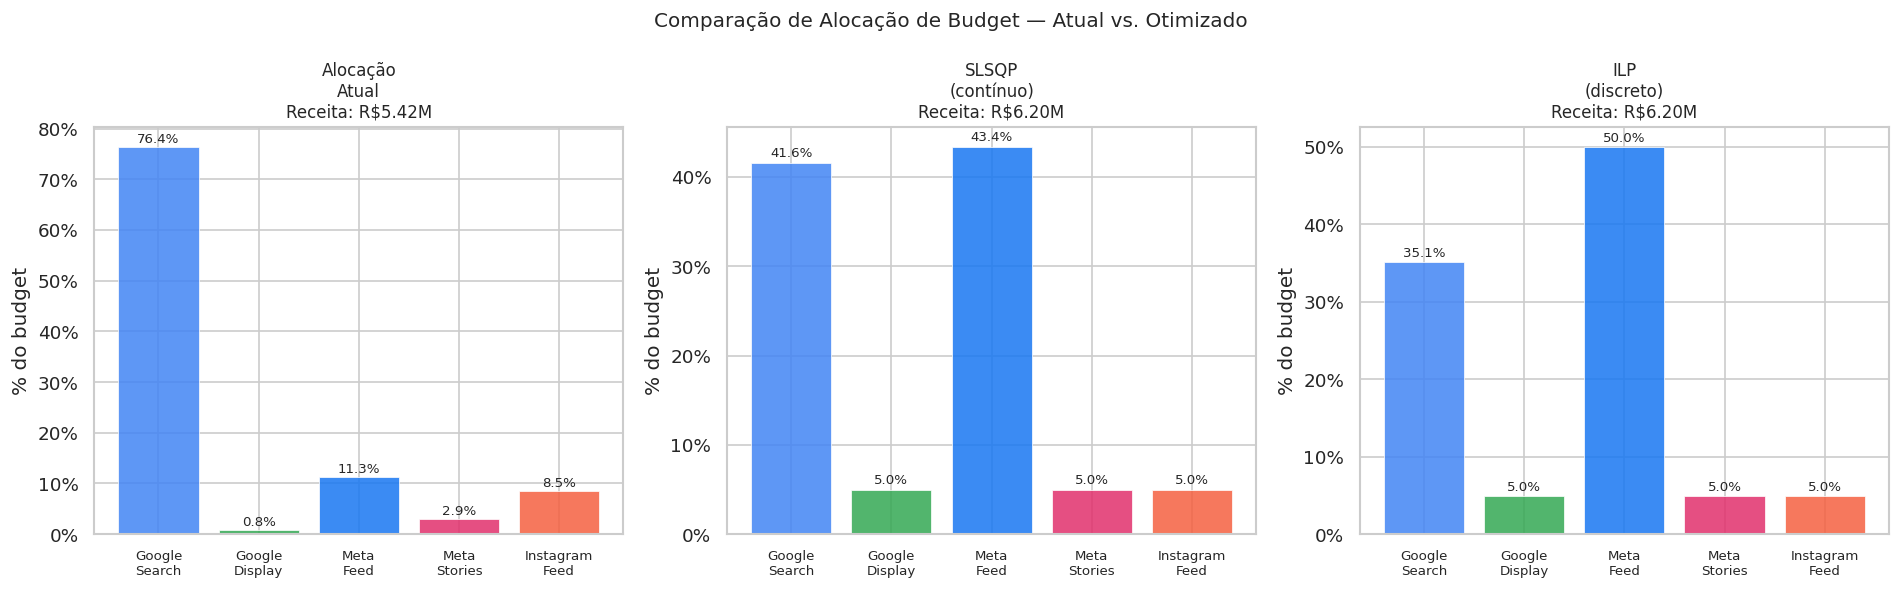


SLSQP vs. ILP — diferença de alocação por canal:
  Google Search         Δ = R$  -152,115
  Google Display        Δ = R$      -695
  Meta Feed             Δ = R$  +153,295
  Meta Stories          Δ = R$      -695
  Instagram Feed        Δ = R$      -695

Diferença de receita esperada: R$+4,848


In [18]:
# Visualização comparativa: alocação atual vs. SLSQP vs. ILP
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cenarios = {
    'Alocação\nAtual':   alocacao_atual.to_dict(),
    'SLSQP\n(contínuo)': alocacao_slsqp,
    'ILP\n(discreto)':   alocacao_ilp,
}

receitas = {
    'Alocação\nAtual':   receita_atual,
    'SLSQP\n(contínuo)': receita_slsqp,
    'ILP\n(discreto)':   receita_ilp,
}

for ax, (nome, alocacao) in zip(axes, cenarios.items()):
    spends = [alocacao.get(ch, 0) for ch in channels]
    total  = sum(spends)
    pcts   = [s / total * 100 for s in spends]
    bar_colors = [CHANNEL_COLORS[c] for c in channels]
    bars = ax.bar(range(len(channels)), pcts, color=bar_colors, alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(channels)))
    ax.set_xticklabels([c.replace(' ', '\n') for c in channels], fontsize=8)
    ax.set_ylabel('% do budget')
    ax.set_title(f'{nome}\nReceita: R${receitas[nome]/1e6:.2f}M', fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparação de Alocação de Budget — Atual vs. Otimizado', fontsize=12)
plt.tight_layout()
plt.savefig('reports/figures/05_budget_optimization.png', bbox_inches='tight')
plt.show()

# Comparação numérica SLSQP vs ILP
print('\nSLSQP vs. ILP — diferença de alocação por canal:')
for ch in channels:
    diff = alocacao_ilp.get(ch, 0) - alocacao_slsqp.get(ch, 0)
    print(f'  {ch:<20}  Δ = R${diff:>+10,.0f}')
print(f'\nDiferença de receita esperada: R${receita_ilp - receita_slsqp:+,.0f}')


## 7. Síntese e tabela de resultados

Consolidação de todos os resultados do notebook em formato exportável para o README e portfólio.

In [19]:
print('=' * 65)
print('SÍNTESE — ANÁLISE DE MÍDIA PAGA (2023)')
print('=' * 65)

print('\n── EDA ──────────────────────────────────────────────────────')
print(f'  Campanhas analisadas:  {len(df):,}')
print(f'  Investimento total:    R${df.spend.sum():,.0f}')
print(f'  Receita total:         R${df.revenue.sum():,.0f}')
print(f'  ROAS geral:            {df.revenue.sum()/df.spend.sum():.2f}x')
print(f'  Melhor canal (ROAS):   {roas_by_ch.index[0]} ({roas_by_ch.iloc[0]:.2f}x)')

print('\n── ATTRIBUTION MODELING ─────────────────────────────────────')
print(f'  {"Canal":<20} {"Last-Click":>12} {"Linear":>10} {"Time-Decay":>12} {"Shapley":>10}')
for ch in channels:
    lc = df_attr_pct.loc[ch, 'Last-Click'] if ch in df_attr_pct.index else 0
    li = df_attr_pct.loc[ch, 'Linear'] if ch in df_attr_pct.index else 0
    td = df_attr_pct.loc[ch, 'Time-Decay'] if ch in df_attr_pct.index else 0
    sh = df_attr_pct.loc[ch, 'Shapley Values'] if ch in df_attr_pct.index else 0
    print(f'  {ch:<20} {lc:>11.1f}% {li:>9.1f}% {td:>11.1f}% {sh:>9.1f}%')

# Canal mais beneficiado pelo Shapley vs Last-Click
maior_ganho = delta.idxmax()
maior_perda = delta.idxmin()
print(f'\n  Mais beneficiado pelo Shapley: {maior_ganho} ({delta[maior_ganho]:+.1f}p.p.)')
print(f'  Mais penalizado pelo Shapley:  {maior_perda} ({delta[maior_perda]:+.1f}p.p.)')

print('\n── BUDGET OPTIMIZATION ──────────────────────────────────────')
print(f'  Budget total:          R${BUDGET_TOTAL:,.0f}')
print(f'  Receita atual:         R${receita_atual:,.0f}  (ROAS: {receita_atual/BUDGET_TOTAL:.2f}x)')
print(f'  Receita SLSQP:         R${receita_slsqp:,.0f}  (ROAS: {receita_slsqp/BUDGET_TOTAL:.2f}x)')
print(f'  Receita ILP:           R${receita_ilp:,.0f}  (ROAS: {receita_ilp/BUDGET_TOTAL:.2f}x)')
print(f'  Ganho SLSQP vs atual:  +{(receita_slsqp/receita_atual-1):.1%}')
print(f'  Ganho ILP vs atual:    +{(receita_ilp/receita_atual-1):.1%}')
print(f'  Diferença SLSQP vs ILP: {(receita_slsqp/receita_ilp-1):.2%} '
      f'(custo da granularidade discreta)')

print('\n── CONCLUSÃO ────────────────────────────────────────────────')
print(f'  O modelo Last-Click subestima canais de topo de funil')
print(f'  ({maior_ganho}) em {abs(delta[maior_ganho]):.1f}p.p. vs. Shapley.')
print(f'  A realocação de budget baseada em Shapley + SLSQP')
print(f'  eleva o ROAS esperado em {(receita_slsqp/receita_atual-1):.1%} sem aumento de budget.')

# Exportar resultados para JSON
resultados = {
    'eda': {
        'n_campanhas': len(df),
        'spend_total': round(df.spend.sum(), 2),
        'revenue_total': round(df.revenue.sum(), 2),
        'roas_geral': round(df.revenue.sum()/df.spend.sum(), 4)
    },
    'attribution': {
        modelo: {ch: round(df_attr_pct.loc[ch, modelo], 2)
                 for ch in channels if ch in df_attr_pct.index}
        for modelo in df_attr_pct.columns
    },
    'optimization': {
        'budget_total': round(BUDGET_TOTAL, 2),
        'receita_atual': round(receita_atual, 2),
        'receita_slsqp': round(receita_slsqp, 2),
        'receita_ilp': round(receita_ilp, 2),
        'roas_atual': round(receita_atual/BUDGET_TOTAL, 4),
        'roas_slsqp': round(receita_slsqp/BUDGET_TOTAL, 4),
        'roas_ilp': round(receita_ilp/BUDGET_TOTAL, 4),
        'alocacao_slsqp': {ch: round(v, 2) for ch, v in alocacao_slsqp.items()},
        'alocacao_ilp': {ch: round(v, 2) for ch, v in alocacao_ilp.items()},
    }
}

os.makedirs('reports', exist_ok=True)
with open('reports/resultados.json', 'w') as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)

print('\nResultados exportados para reports/resultados.json')

SÍNTESE — ANÁLISE DE MÍDIA PAGA (2023)

── EDA ──────────────────────────────────────────────────────
  Campanhas analisadas:  2,000
  Investimento total:    R$2,333,905
  Receita total:         R$5,422,499
  ROAS geral:            2.32x
  Melhor canal (ROAS):   Meta Feed (2.27x)

── ATTRIBUTION MODELING ─────────────────────────────────────
  Canal                  Last-Click     Linear   Time-Decay    Shapley
  Google Search               45.8%      34.1%        34.8%      34.1%
  Google Display               5.9%      15.8%        15.2%      15.4%
  Meta Feed                   27.0%      23.6%        23.8%      23.7%
  Meta Stories                 9.6%      13.4%        13.2%      13.6%
  Instagram Feed              11.7%      13.1%        13.0%      13.2%

  Mais beneficiado pelo Shapley: Google Display (+9.5p.p.)
  Mais penalizado pelo Shapley:  Google Search (-11.8p.p.)

── BUDGET OPTIMIZATION ──────────────────────────────────────
  Budget total:          R$2,333,905
  Receita a

## 8. Conclusão

**O modelo Last-Click distorce sistematicamente a atribuição — e induz alocações de budget subótimas.**

Os principais achados:

- **Last-Click supervaloriza Google Search em −11,8 p.p.:** o canal captura o clique final, mas frequentemente o usuário chegou via Display ou Stories antes. O modelo atribui R$ 626.556 a mais de crédito do que o Shapley indica
- **Last-Click subvaloriza Google Display em +9,5 p.p.:** o canal raramente é o último clique, mas aparece no início de boa parte das jornadas que convertem. R$ 506.873 a menos de crédito do que merece
- **Linear e Time-Decay chegam a conclusões semelhantes ao Shapley**, mas sem o embasamento axiomático — o Shapley é o único modelo que satisfaz eficiência, simetria, nulidade e aditividade simultaneamente
- **A realocação baseada em Shapley + ILP eleva o ROAS esperado de 2,32× para 2,66×** — ganho de +14,3% de receita (R$ 777.906) sem aumento de budget, redistribuindo investimento de Google Search (saturado) para Meta Feed e Google Display (subinvestidos)
- **A diferença entre SLSQP e ILP é de apenas R$ 4.848 (−0,08%)** — o custo da granularidade discreta é negligenciável nesta escala. O ILP é preferível operacionalmente por gerar alocações em múltiplos de R$ 1.000, compatíveis com os mínimos das plataformas
